# Confidence 1/2 Loss Weight Sweep

This notebook repeats the 04-style MLP experiment while sweeping several loss weights for confidence 1 and 2.

- Input: audio embedding + text embedding + class one-hot + 4 similarity/margin features
- Model: Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)
- Tasks: 5-class confidence classification and binary 123 vs 45 classification
- Goal: compare how strongly weighting confidence 1/2 improves low-confidence detection and how much it hurts high-confidence recall

In [1]:
from pathlib import Path
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 32
DROPOUT = 0.2
LABELS = [1, 2, 3, 4, 5]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# You can edit this list freely.
# w1 = loss weight for confidence 1, w2 = loss weight for confidence 2.
LOSS_WEIGHT_SWEEP = [
    {'tag': 'baseline_w1_1_w2_1', 'w1': 1.0, 'w2': 1.0},
    {'tag': 'mild_w1_5_w2_1p5', 'w1': 5.0, 'w2': 1.5},
    {'tag': 'medium_w1_10_w2_2', 'w1': 10.0, 'w2': 2.0},
    {'tag': 'current_w1_20p54_w2_2p93', 'w1': 20.540625, 'w2': 2.927839643652561},
    {'tag': 'strong_w1_30_w2_4', 'w1': 30.0, 'w2': 4.0},
    {'tag': 'very_strong_w1_40_w2_6', 'w1': 40.0, 'w2': 6.0},
]

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('DEVICE:', DEVICE)
print('configs:', len(LOSS_WEIGHT_SWEEP))

DEVICE: cuda
configs: 6


In [2]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd().resolve()

if HERE.name == 'deft논문기반_실험':
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

METADATA_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
TEXT_SIM_CSV = EXP_DIR / 'audio_text_sim_confidence_outputs' / 'audio_text_similarity_with_bin_predictions.csv'
CLASS_SIM_CSV = EXP_DIR / 'audio_class_sim_confidence_outputs' / 'audio_class_similarity_with_bin_predictions.csv'
MARGIN_CSV = EXP_DIR / 'clap_similarity_margin_outputs' / 'clap_similarity_margin_features.csv'

OUT_DIR = EXP_DIR / 'weighted_loss_confidence12_sweep_outputs'
PLOT_DIR = OUT_DIR / 'plots'
REPORT_DIR = OUT_DIR / 'reports'
PRED_DIR = OUT_DIR / 'predictions'
MODEL_DIR = OUT_DIR / 'models'
for p in [OUT_DIR, PLOT_DIR, REPORT_DIR, PRED_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [METADATA_CSV, AUDIO_EMB_DIR, TEXT_EMB_DIR, TEXT_SIM_CSV, CLASS_SIM_CSV, MARGIN_CSV]:
    print(p, 'exists:', p.exists())
print('OUT_DIR:', OUT_DIR)

C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_text_sim_confidence_outputs\audio_text_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\audio_class_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\clap_similarity_margin_features.csv exists: True
OUT_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\weighted_loss_confidence12_sweep_outputs


In [3]:
SCALAR_FEATURE_COLS = ['audio_text_sim', 'audio_class_sim', 'audio_assigned_label_margin', 'text_assigned_label_margin']
FEATURE_DESCRIPTION = 'audio_embedding_512 + text_embedding_512 + class_one_hot + similarity_margin_4'
MODEL_DESCRIPTION = 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)'

meta = pd.read_csv(METADATA_CSV)
audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows, audio_list, text_list = [], [], []
for _, row in meta.iterrows():
    sound_id = str(row['sound_id'])
    if sound_id not in audio_paths or sound_id not in text_paths:
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        continue
    if confidence not in LABELS:
        continue
    rows.append({'sound_id': sound_id, 'class': row['class'], 'confidence': confidence})
    audio_list.append(np.load(audio_paths[sound_id]).reshape(-1).astype(np.float32))
    text_list.append(np.load(text_paths[sound_id]).reshape(-1).astype(np.float32))

df = pd.DataFrame(rows)
df['_row_idx'] = np.arange(len(df))
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

text_sim_df = pd.read_csv(TEXT_SIM_CSV)[['sound_id', 'audio_text_sim']]
class_sim_df = pd.read_csv(CLASS_SIM_CSV)[['sound_id', 'audio_class_sim']]
margin_df = pd.read_csv(MARGIN_CSV)[['sound_id', 'audio_assigned_label_margin', 'text_assigned_label_margin']]
for part_df in [text_sim_df, class_sim_df, margin_df]:
    part_df['sound_id'] = part_df['sound_id'].astype(str)

df = df.merge(text_sim_df, on='sound_id', how='left')
df = df.merge(class_sim_df, on='sound_id', how='left')
df = df.merge(margin_df, on='sound_id', how='left')
df = df.dropna(subset=SCALAR_FEATURE_COLS).reset_index(drop=True)

keep_idx = df['_row_idx'].to_numpy(dtype=np.int64)
audio_emb = audio_emb[keep_idx]
text_emb = text_emb[keep_idx]
scalar_features = df[SCALAR_FEATURE_COLS].to_numpy(dtype=np.float32)

class_categories = sorted(df['class'].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(class_categories)}
class_ids = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
class_onehot = np.eye(len(class_categories), dtype=np.float32)[class_ids]

X_full = np.concatenate([audio_emb, text_emb, class_onehot, scalar_features], axis=1).astype(np.float32)
y_confidence = df['confidence'].to_numpy(dtype=np.int64)
y_5class = y_confidence - 1
y_binary = (y_confidence >= 4).astype(np.int64)
df['class_idx'] = class_ids
df['binary_confidence'] = y_binary
df = df.drop(columns=['_row_idx'])

df.to_csv(REPORT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')
(REPORT_DIR / 'class_mapping.json').write_text(json.dumps(class_to_idx, indent=2, ensure_ascii=False), encoding='utf-8')

idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y_confidence)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y_confidence[temp_idx])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[train_idx]).astype(np.float32)
X_val = scaler.transform(X_full[val_idx]).astype(np.float32)
X_test = scaler.transform(X_full[test_idx]).astype(np.float32)

split_df = pd.DataFrame({'sound_id': df['sound_id'], 'split': 'train'})
split_df.loc[val_idx, 'split'] = 'val'
split_df.loc[test_idx, 'split'] = 'test'
split_df.to_csv(REPORT_DIR / 'splits.csv', index=False, encoding='utf-8-sig')

print('rows:', len(df))
print('X_full:', X_full.shape)
display(pd.crosstab(split_df['split'], df['confidence'], rownames=['split'], colnames=['confidence']))

rows: 10956
X_full: (10956, 1051)


confidence,1,2,3,4,5
split,,,,,
test,16,112,492,907,117
train,74,524,2296,4232,543
val,16,113,492,906,116


In [4]:
class OneLayerMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

def make_loader(X_arr, y_arr, sample_weights=None, shuffle=False):
    if sample_weights is None:
        sample_weights = np.ones(len(y_arr), dtype=np.float32)
    ds = TensorDataset(torch.from_numpy(X_arr), torch.from_numpy(y_arr.astype(np.int64)), torch.from_numpy(sample_weights.astype(np.float32)))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def weighted_cross_entropy(logits, y, sample_weight):
    per_sample = nn.functional.cross_entropy(logits, y, reduction='none')
    return (per_sample * sample_weight).sum() / sample_weight.sum().clamp_min(1e-8)

def get_sample_weights(confidence_values, w1, w2):
    weight_map = {1: float(w1), 2: float(w2), 3: 1.0, 4: 1.0, 5: 1.0}
    return np.array([weight_map[int(c)] for c in confidence_values], dtype=np.float32)

def compute_metrics(y_true, y_pred, one_based_mae=False):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_true + 1, y_pred + 1) if one_based_mae else mean_absolute_error(y_true, y_pred)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': p_macro,
        'macro_recall': r_macro,
        'macro_f1': f1_macro,
        'weighted_precision': p_weighted,
        'weighted_recall': r_weighted,
        'weighted_f1': f1_weighted,
        'mae': mae,
    }

def train_model(task_name, X_train, y_train, X_val, y_val, train_weights, output_dim, one_based_mae=False):
    seed_everything(SEED)
    model = OneLayerMLP(X_train.shape[1], output_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader(X_train, y_train, train_weights, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)

    best_state = None
    best_epoch = 0
    best_val_loss = float('inf')
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        train_weight_sum = 0.0
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = weighted_cross_entropy(logits, yb, wb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * float(wb.sum().item())
            train_weight_sum += float(wb.sum().item())

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        all_true, all_pred = [], []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_loss_sum += nn.functional.cross_entropy(logits, yb, reduction='sum').item()
                n_val += len(yb)
                all_true.append(yb.cpu().numpy())
                all_pred.append(logits.argmax(dim=1).cpu().numpy())

        y_true_epoch = np.concatenate(all_true)
        y_pred_epoch = np.concatenate(all_pred)
        val_loss = val_loss_sum / n_val
        epoch_metrics = compute_metrics(y_true_epoch, y_pred_epoch, one_based_mae=one_based_mae)
        history.append({'epoch': epoch, 'train_loss': train_loss_sum / max(train_weight_sum, 1e-8), 'val_loss': val_loss, **epoch_metrics})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(REPORT_DIR / f'{task_name}_history.csv', index=False, encoding='utf-8-sig')
    return model, history_df, {'best_epoch': best_epoch, 'best_val_loss': best_val_loss}

def predict(model, X_arr):
    loader = DataLoader(torch.from_numpy(X_arr), batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    preds, probs = [], []
    with torch.no_grad():
        for xb in loader:
            prob = torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy()
            probs.append(prob)
            preds.append(prob.argmax(axis=1))
    return np.concatenate(preds), np.concatenate(probs)

def save_confusion(cm, labels, title, path):
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm, vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.show()
    return cm_norm


Running baseline_w1_1_w2_1: confidence1=1.0, confidence2=1.0


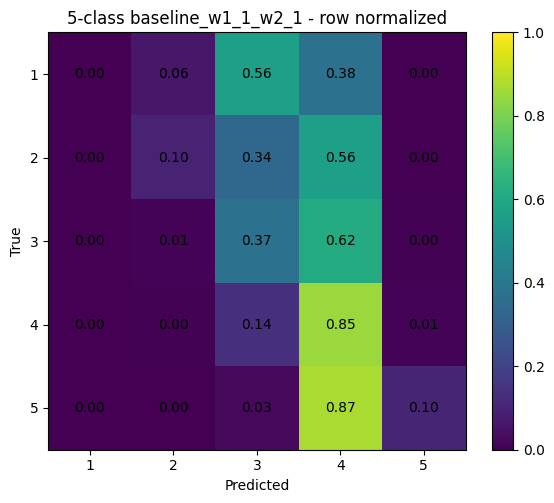

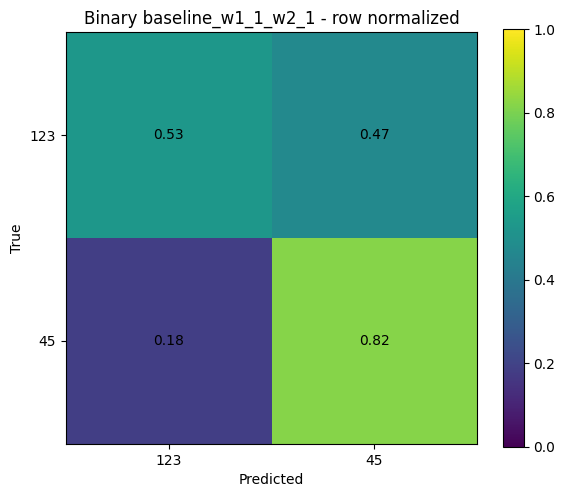

tag                         baseline_w1_1_w2_1
w1                                         1.0
w2                                         1.0
5class_best_epoch                            4
5class_test_accuracy                  0.593674
5class_test_macro_f1                  0.296886
5class_test_macro_recall              0.284336
5class_test_mae                       0.462895
5class_recall_1                            0.0
5class_recall_2                       0.098214
5class_recall_3                       0.371951
5class_recall_4                       0.848953
5class_recall_5                       0.102564
binary_best_epoch                            4
binary_test_accuracy                  0.708637
binary_test_macro_f1                  0.678014
binary_test_macro_recall              0.673526
binary_recall_123                     0.530645
binary_recall_45                      0.816406
dtype: object

Running mild_w1_5_w2_1p5: confidence1=5.0, confidence2=1.5


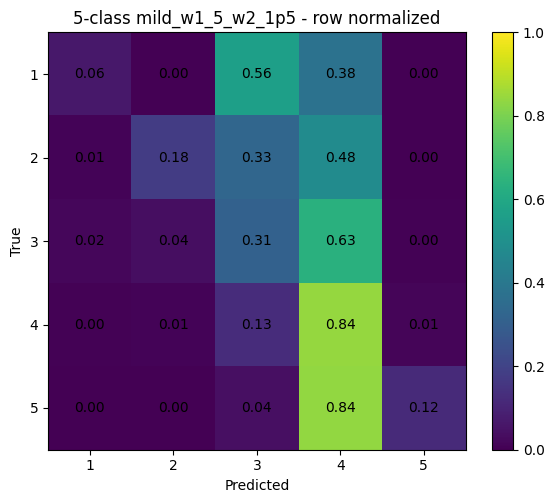

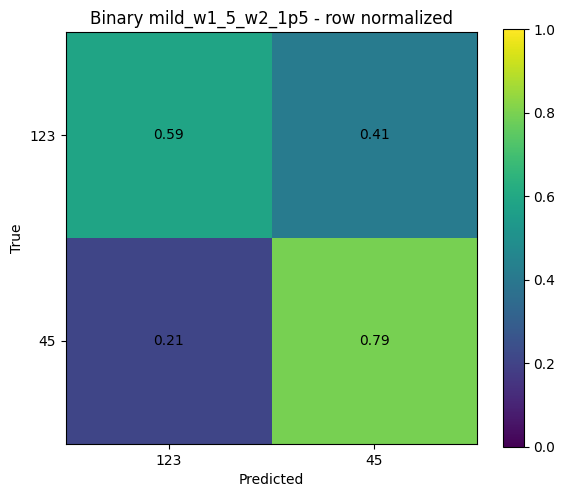

tag                         mild_w1_5_w2_1p5
w1                                       5.0
w2                                       1.5
5class_best_epoch                          4
5class_test_accuracy                0.579075
5class_test_macro_f1                0.319608
5class_test_macro_recall            0.302623
5class_test_mae                     0.486618
5class_recall_1                       0.0625
5class_recall_2                     0.178571
5class_recall_3                     0.308943
5class_recall_4                      0.84344
5class_recall_5                     0.119658
binary_best_epoch                          4
binary_test_accuracy                 0.71472
binary_test_macro_f1                0.691726
binary_test_macro_recall            0.689226
binary_recall_123                   0.585484
binary_recall_45                    0.792969
dtype: object

Running medium_w1_10_w2_2: confidence1=10.0, confidence2=2.0


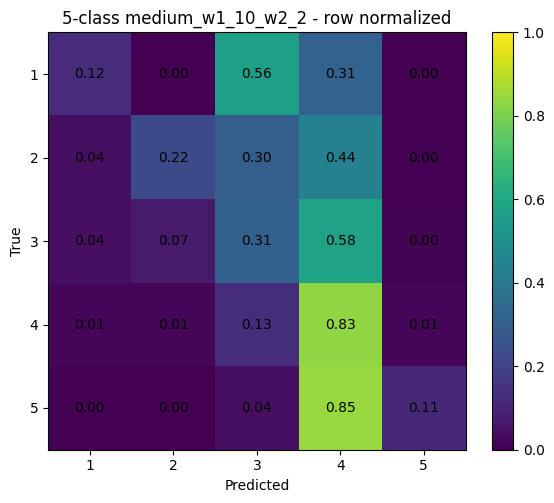

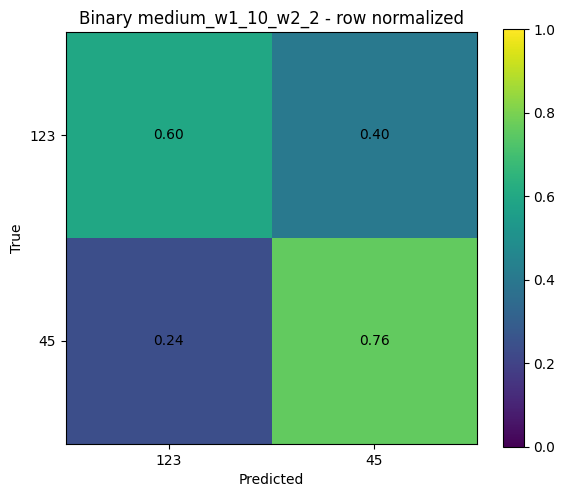

tag                         medium_w1_10_w2_2
w1                                       10.0
w2                                        2.0
5class_best_epoch                           8
5class_test_accuracy                 0.576034
5class_test_macro_f1                 0.324654
5class_test_macro_recall             0.320137
5class_test_mae                      0.502433
5class_recall_1                         0.125
5class_recall_2                      0.223214
5class_recall_3                      0.308943
5class_recall_4                      0.832415
5class_recall_5                      0.111111
binary_best_epoch                           4
binary_test_accuracy                 0.698297
binary_test_macro_f1                 0.678288
binary_test_macro_recall             0.677952
binary_recall_123                    0.595161
binary_recall_45                     0.760742
dtype: object

Running current_w1_20p54_w2_2p93: confidence1=20.540625, confidence2=2.927839643652561


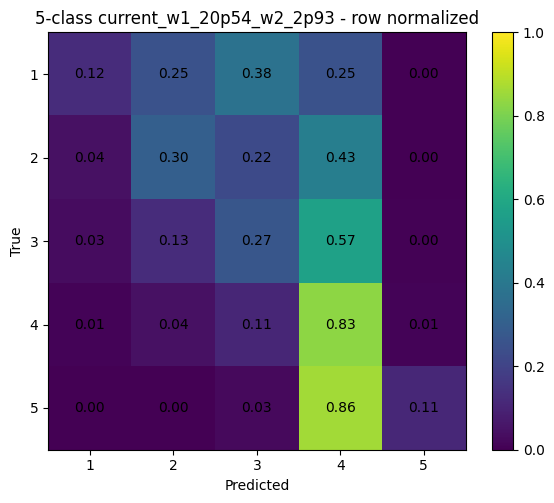

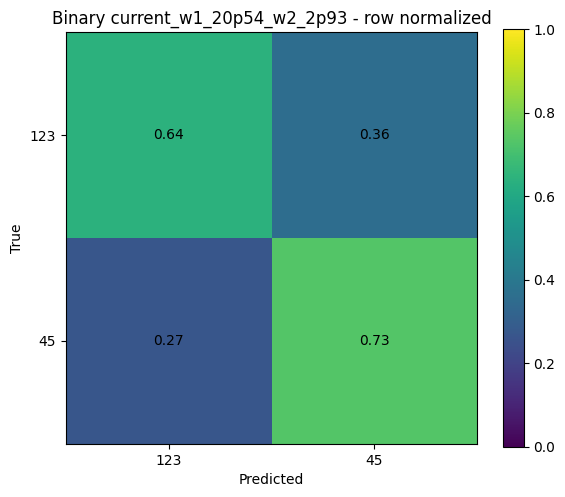

tag                         current_w1_20p54_w2_2p93
w1                                         20.540625
w2                                           2.92784
5class_best_epoch                                 13
5class_test_accuracy                        0.567518
5class_test_macro_f1                        0.321113
5class_test_macro_recall                     0.32723
5class_test_mae                             0.518248
5class_recall_1                                0.125
5class_recall_2                             0.303571
5class_recall_3                              0.26626
5class_recall_4                             0.830209
5class_recall_5                             0.111111
binary_best_epoch                                  4
binary_test_accuracy                        0.698905
binary_test_macro_f1                        0.684352
binary_test_macro_recall                    0.687667
binary_recall_123                           0.641935
binary_recall_45                            0.

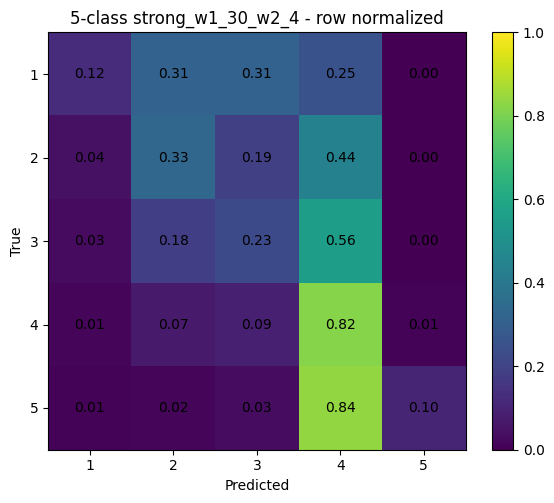

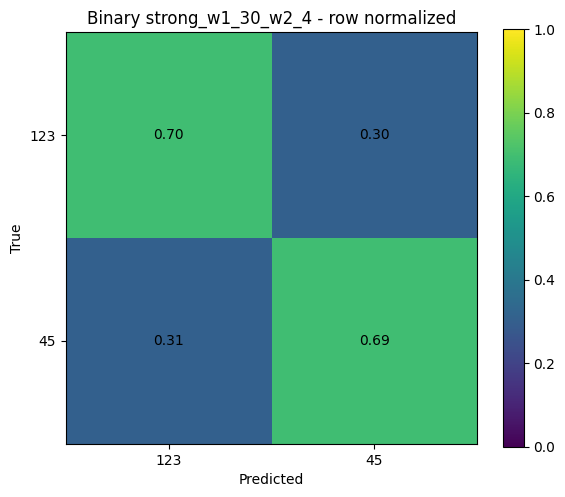

tag                         strong_w1_30_w2_4
w1                                       30.0
w2                                        4.0
5class_best_epoch                          13
5class_test_accuracy                 0.549878
5class_test_macro_f1                  0.30338
5class_test_macro_recall             0.320323
5class_test_mae                      0.557178
5class_recall_1                         0.125
5class_recall_2                      0.330357
5class_recall_3                       0.22561
5class_recall_4                      0.818082
5class_recall_5                      0.102564
binary_best_epoch                           4
binary_test_accuracy                 0.694039
binary_test_macro_f1                 0.684966
binary_test_macro_recall              0.69426
binary_recall_123                    0.695161
binary_recall_45                     0.693359
dtype: object

Running very_strong_w1_40_w2_6: confidence1=40.0, confidence2=6.0


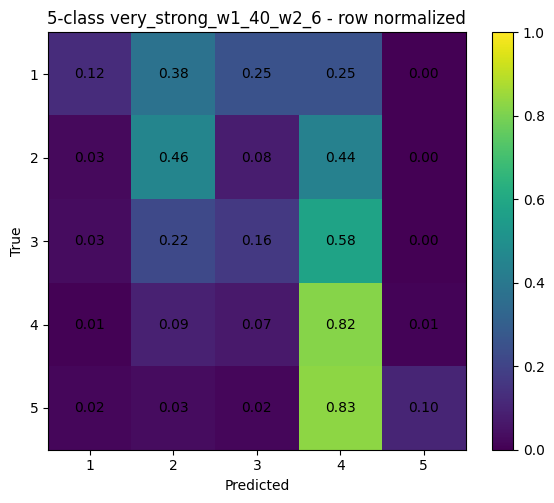

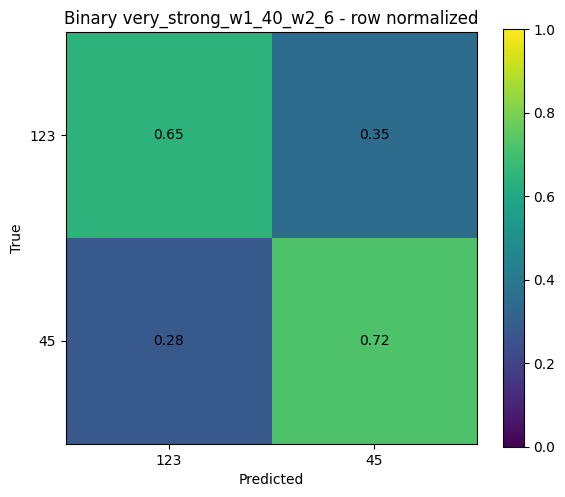

tag                         very_strong_w1_40_w2_6
w1                                            40.0
w2                                             6.0
5class_best_epoch                               19
5class_test_accuracy                      0.541363
5class_test_macro_f1                      0.300181
5class_test_macro_recall                  0.333568
5class_test_mae                           0.574209
5class_recall_1                              0.125
5class_recall_2                           0.455357
5class_recall_3                           0.164634
5class_recall_4                           0.820287
5class_recall_5                           0.102564
binary_best_epoch                               13
binary_test_accuracy                      0.694039
binary_test_macro_f1                      0.680619
binary_test_macro_recall                  0.685033
binary_recall_123                         0.648387
binary_recall_45                           0.72168
dtype: object


,tag,w1,w2,5class_best_epoch,5class_test_accuracy,5class_test_macro_f1,5class_test_macro_recall,5class_test_mae,5class_recall_1,5class_recall_2,5class_recall_3,5class_recall_4,5class_recall_5,binary_best_epoch,binary_test_accuracy,binary_test_macro_f1,binary_test_macro_recall,binary_recall_123,binary_recall_45
0,baseline_w1_1_w2_1,1.000000,1.00000,4,0.593674,0.296886,0.284336,0.462895,0.0000,0.098214,0.371951,0.848953,0.102564,4,0.708637,0.678014,0.673526,0.530645,0.816406
1,mild_w1_5_w2_1p5,5.000000,1.50000,4,0.579075,0.319608,0.302623,0.486618,0.0625,0.178571,0.308943,0.843440,0.119658,4,0.714720,0.691726,0.689226,0.585484,0.792969
2,medium_w1_10_w2_2,10.000000,2.00000,8,0.576034,0.324654,0.320137,0.502433,0.1250,0.223214,0.308943,0.832415,0.111111,4,0.698297,0.678288,0.677952,0.595161,0.760742
3,current_w1_20p54_w2_2p93,20.540625,2.92784,13,0.567518,0.321113,0.327230,0.518248,0.1250,0.303571,0.266260,0.830209,0.111111,4,0.698905,0.684352,0.687667,0.641935,0.733398
4,strong_w1_30_w2_4,30.000000,4.00000,13,0.549878,0.303380,0.320323,0.557178,0.1250,0.330357,0.225610,0.818082,0.102564,4,0.694039,0.684966,0.694260,0.695161,0.693359
5,very_strong_w1_40_w2_6,40.000000,6.00000,19,0.541363,0.300181,0.333568,0.574209,0.1250,0.455357,0.164634,0.820287,0.102564,13,0.694039,0.680619,0.685033,0.648387,0.721680


In [5]:
def run_one_config(config):
    tag = config['tag']
    w1 = config['w1']
    w2 = config['w2']
    print('\n' + '=' * 80)
    print(f'Running {tag}: confidence1={w1}, confidence2={w2}')

    train_weights = get_sample_weights(y_confidence[train_idx], w1=w1, w2=w2)
    weight_plan = pd.DataFrame({
        'confidence': LABELS,
        'train_count': [int((y_confidence[train_idx] == c).sum()) for c in LABELS],
        'loss_weight': [w1, w2, 1.0, 1.0, 1.0],
    })
    weight_plan.to_csv(REPORT_DIR / f'{tag}_weight_plan.csv', index=False, encoding='utf-8-sig')

    y5_train, y5_val, y5_test = y_5class[train_idx], y_5class[val_idx], y_5class[test_idx]
    model5, history5, best5 = train_model(f'{tag}_5class', X_train, y5_train, X_val, y5_val, train_weights, output_dim=5, one_based_mae=True)
    pred5, prob5 = predict(model5, X_test)
    true5_label, pred5_label = y5_test + 1, pred5 + 1
    cm5 = confusion_matrix(true5_label, pred5_label, labels=LABELS)
    cm5_norm = save_confusion(cm5, LABELS, f'5-class {tag} - row normalized', PLOT_DIR / f'{tag}_5class_confusion_row_normalized.png')
    report5 = classification_report(true5_label, pred5_label, labels=LABELS, target_names=[f'confidence_{x}' for x in LABELS], output_dict=True, zero_division=0)
    report5_text = classification_report(true5_label, pred5_label, labels=LABELS, target_names=[f'confidence_{x}' for x in LABELS], digits=4, zero_division=0)
    (REPORT_DIR / f'{tag}_5class_report.txt').write_text(report5_text, encoding='utf-8')
    pd.DataFrame(cm5, index=[f'true_{x}' for x in LABELS], columns=[f'pred_{x}' for x in LABELS]).to_csv(REPORT_DIR / f'{tag}_5class_confusion_counts.csv', encoding='utf-8-sig')
    pd.DataFrame(cm5_norm, index=[f'true_{x}' for x in LABELS], columns=[f'pred_{x}' for x in LABELS]).to_csv(REPORT_DIR / f'{tag}_5class_confusion_row_normalized.csv', encoding='utf-8-sig')
    pd.DataFrame({'sound_id': df.loc[test_idx, 'sound_id'].values, 'true_confidence': true5_label, 'pred_confidence': pred5_label, 'prob_max': prob5.max(axis=1)}).to_csv(PRED_DIR / f'{tag}_5class_predictions.csv', index=False, encoding='utf-8-sig')
    torch.save({'model_state_dict': model5.state_dict(), 'tag': tag, 'w1': w1, 'w2': w2, 'feature_description': FEATURE_DESCRIPTION, 'model_description': MODEL_DESCRIPTION}, MODEL_DIR / f'{tag}_5class.pt')

    yb_train, yb_val, yb_test = y_binary[train_idx], y_binary[val_idx], y_binary[test_idx]
    modelb, historyb, bestb = train_model(f'{tag}_binary', X_train, yb_train, X_val, yb_val, train_weights, output_dim=2, one_based_mae=False)
    predb, probb = predict(modelb, X_test)
    cmb = confusion_matrix(yb_test, predb, labels=[0, 1])
    cmb_norm = save_confusion(cmb, ['123', '45'], f'Binary {tag} - row normalized', PLOT_DIR / f'{tag}_binary_confusion_row_normalized.png')
    reportb = classification_report(yb_test, predb, labels=[0, 1], target_names=['confidence_123', 'confidence_45'], output_dict=True, zero_division=0)
    reportb_text = classification_report(yb_test, predb, labels=[0, 1], target_names=['confidence_123', 'confidence_45'], digits=4, zero_division=0)
    (REPORT_DIR / f'{tag}_binary_report.txt').write_text(reportb_text, encoding='utf-8')
    pd.DataFrame(cmb, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45']).to_csv(REPORT_DIR / f'{tag}_binary_confusion_counts.csv', encoding='utf-8-sig')
    pd.DataFrame(cmb_norm, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45']).to_csv(REPORT_DIR / f'{tag}_binary_confusion_row_normalized.csv', encoding='utf-8-sig')
    pd.DataFrame({'sound_id': df.loc[test_idx, 'sound_id'].values, 'true_binary': yb_test, 'pred_binary': predb, 'prob_123': probb[:, 0], 'prob_45': probb[:, 1], 'original_confidence': y_confidence[test_idx]}).to_csv(PRED_DIR / f'{tag}_binary_predictions.csv', index=False, encoding='utf-8-sig')
    torch.save({'model_state_dict': modelb.state_dict(), 'tag': tag, 'w1': w1, 'w2': w2, 'feature_description': FEATURE_DESCRIPTION, 'model_description': MODEL_DESCRIPTION}, MODEL_DIR / f'{tag}_binary.pt')

    metrics5 = compute_metrics(y5_test, pred5, one_based_mae=True)
    metricsb = compute_metrics(yb_test, predb, one_based_mae=False)
    result = {
        'tag': tag,
        'w1': w1,
        'w2': w2,
        '5class_best_epoch': best5['best_epoch'],
        '5class_test_accuracy': metrics5['accuracy'],
        '5class_test_macro_f1': metrics5['macro_f1'],
        '5class_test_macro_recall': metrics5['macro_recall'],
        '5class_test_mae': metrics5['mae'],
        '5class_recall_1': float(cm5_norm[0, 0]),
        '5class_recall_2': float(cm5_norm[1, 1]),
        '5class_recall_3': float(cm5_norm[2, 2]),
        '5class_recall_4': float(cm5_norm[3, 3]),
        '5class_recall_5': float(cm5_norm[4, 4]),
        'binary_best_epoch': bestb['best_epoch'],
        'binary_test_accuracy': metricsb['accuracy'],
        'binary_test_macro_f1': metricsb['macro_f1'],
        'binary_test_macro_recall': metricsb['macro_recall'],
        'binary_recall_123': float(cmb_norm[0, 0]),
        'binary_recall_45': float(cmb_norm[1, 1]),
    }
    print(pd.Series(result))
    return result

all_results = []
for config in LOSS_WEIGHT_SWEEP:
    all_results.append(run_one_config(config))

results_df = pd.DataFrame(all_results)
results_df.to_csv(REPORT_DIR / 'loss_weight_sweep_summary.csv', index=False, encoding='utf-8-sig')
display(results_df)

Best 5-class macro F1


,tag,w1,w2,5class_test_accuracy,5class_test_macro_f1,5class_test_mae,5class_recall_1,5class_recall_2,binary_test_macro_f1,binary_recall_123,binary_recall_45
2,medium_w1_10_w2_2,10.000000,2.00000,0.576034,0.324654,0.502433,0.1250,0.223214,0.678288,0.595161,0.760742
3,current_w1_20p54_w2_2p93,20.540625,2.92784,0.567518,0.321113,0.518248,0.1250,0.303571,0.684352,0.641935,0.733398
1,mild_w1_5_w2_1p5,5.000000,1.50000,0.579075,0.319608,0.486618,0.0625,0.178571,0.691726,0.585484,0.792969
4,strong_w1_30_w2_4,30.000000,4.00000,0.549878,0.303380,0.557178,0.1250,0.330357,0.684966,0.695161,0.693359
5,very_strong_w1_40_w2_6,40.000000,6.00000,0.541363,0.300181,0.574209,0.1250,0.455357,0.680619,0.648387,0.721680
0,baseline_w1_1_w2_1,1.000000,1.00000,0.593674,0.296886,0.462895,0.0000,0.098214,0.678014,0.530645,0.816406


Best 5-class MAE


,tag,w1,w2,5class_test_accuracy,5class_test_macro_f1,5class_test_mae,5class_recall_1,5class_recall_2,binary_test_macro_f1,binary_recall_123,binary_recall_45
0,baseline_w1_1_w2_1,1.000000,1.00000,0.593674,0.296886,0.462895,0.0000,0.098214,0.678014,0.530645,0.816406
1,mild_w1_5_w2_1p5,5.000000,1.50000,0.579075,0.319608,0.486618,0.0625,0.178571,0.691726,0.585484,0.792969
2,medium_w1_10_w2_2,10.000000,2.00000,0.576034,0.324654,0.502433,0.1250,0.223214,0.678288,0.595161,0.760742
3,current_w1_20p54_w2_2p93,20.540625,2.92784,0.567518,0.321113,0.518248,0.1250,0.303571,0.684352,0.641935,0.733398
4,strong_w1_30_w2_4,30.000000,4.00000,0.549878,0.303380,0.557178,0.1250,0.330357,0.684966,0.695161,0.693359
5,very_strong_w1_40_w2_6,40.000000,6.00000,0.541363,0.300181,0.574209,0.1250,0.455357,0.680619,0.648387,0.721680


Best binary macro F1


,tag,w1,w2,5class_test_accuracy,5class_test_macro_f1,5class_test_mae,5class_recall_1,5class_recall_2,binary_test_macro_f1,binary_recall_123,binary_recall_45
1,mild_w1_5_w2_1p5,5.000000,1.50000,0.579075,0.319608,0.486618,0.0625,0.178571,0.691726,0.585484,0.792969
4,strong_w1_30_w2_4,30.000000,4.00000,0.549878,0.303380,0.557178,0.1250,0.330357,0.684966,0.695161,0.693359
3,current_w1_20p54_w2_2p93,20.540625,2.92784,0.567518,0.321113,0.518248,0.1250,0.303571,0.684352,0.641935,0.733398
5,very_strong_w1_40_w2_6,40.000000,6.00000,0.541363,0.300181,0.574209,0.1250,0.455357,0.680619,0.648387,0.721680
2,medium_w1_10_w2_2,10.000000,2.00000,0.576034,0.324654,0.502433,0.1250,0.223214,0.678288,0.595161,0.760742
0,baseline_w1_1_w2_1,1.000000,1.00000,0.593674,0.296886,0.462895,0.0000,0.098214,0.678014,0.530645,0.816406


Best low-confidence binary recall


,tag,w1,w2,5class_test_accuracy,5class_test_macro_f1,5class_test_mae,5class_recall_1,5class_recall_2,binary_test_macro_f1,binary_recall_123,binary_recall_45
4,strong_w1_30_w2_4,30.000000,4.00000,0.549878,0.303380,0.557178,0.1250,0.330357,0.684966,0.695161,0.693359
5,very_strong_w1_40_w2_6,40.000000,6.00000,0.541363,0.300181,0.574209,0.1250,0.455357,0.680619,0.648387,0.721680
3,current_w1_20p54_w2_2p93,20.540625,2.92784,0.567518,0.321113,0.518248,0.1250,0.303571,0.684352,0.641935,0.733398
2,medium_w1_10_w2_2,10.000000,2.00000,0.576034,0.324654,0.502433,0.1250,0.223214,0.678288,0.595161,0.760742
1,mild_w1_5_w2_1p5,5.000000,1.50000,0.579075,0.319608,0.486618,0.0625,0.178571,0.691726,0.585484,0.792969
0,baseline_w1_1_w2_1,1.000000,1.00000,0.593674,0.296886,0.462895,0.0000,0.098214,0.678014,0.530645,0.816406


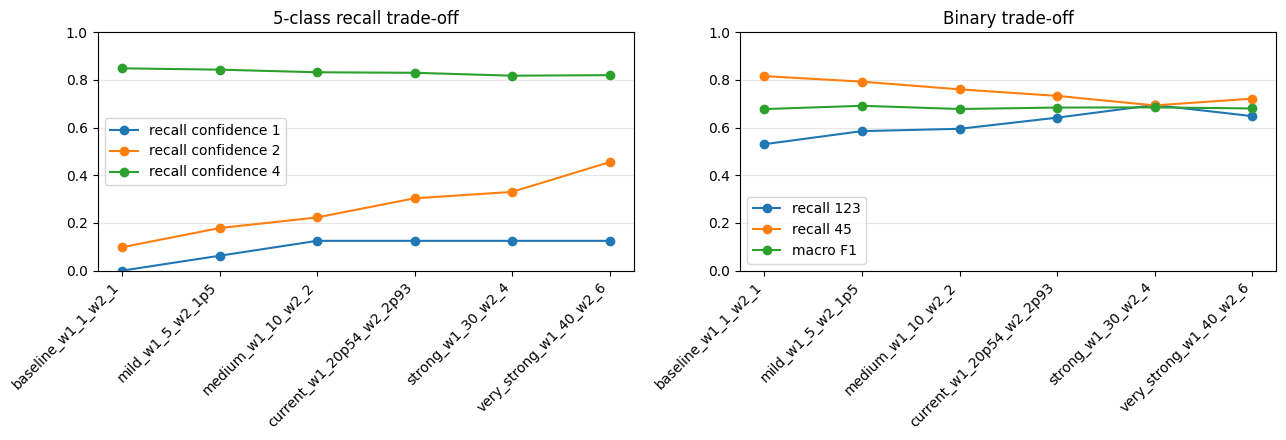

saved: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\weighted_loss_confidence12_sweep_outputs


In [6]:
ranking_cols = ['tag', 'w1', 'w2', '5class_test_accuracy', '5class_test_macro_f1', '5class_test_mae', '5class_recall_1', '5class_recall_2', 'binary_test_macro_f1', 'binary_recall_123', 'binary_recall_45']

print('Best 5-class macro F1')
display(results_df.sort_values('5class_test_macro_f1', ascending=False)[ranking_cols])

print('Best 5-class MAE')
display(results_df.sort_values('5class_test_mae', ascending=True)[ranking_cols])

print('Best binary macro F1')
display(results_df.sort_values('binary_test_macro_f1', ascending=False)[ranking_cols])

print('Best low-confidence binary recall')
display(results_df.sort_values('binary_recall_123', ascending=False)[ranking_cols])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(results_df))
axes[0].plot(x, results_df['5class_recall_1'], marker='o', label='recall confidence 1')
axes[0].plot(x, results_df['5class_recall_2'], marker='o', label='recall confidence 2')
axes[0].plot(x, results_df['5class_recall_4'], marker='o', label='recall confidence 4')
axes[0].set_title('5-class recall trade-off')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['tag'], rotation=45, ha='right')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

axes[1].plot(x, results_df['binary_recall_123'], marker='o', label='recall 123')
axes[1].plot(x, results_df['binary_recall_45'], marker='o', label='recall 45')
axes[1].plot(x, results_df['binary_test_macro_f1'], marker='o', label='macro F1')
axes[1].set_title('Binary trade-off')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['tag'], rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOT_DIR / 'loss_weight_sweep_tradeoff.png', dpi=180)
plt.show()

summary = {
    'feature_description': FEATURE_DESCRIPTION,
    'model_description': MODEL_DESCRIPTION,
    'epochs': EPOCHS,
    'sweep': LOSS_WEIGHT_SWEEP,
    'best_5class_macro_f1': results_df.sort_values('5class_test_macro_f1', ascending=False).iloc[0].to_dict(),
    'best_5class_mae': results_df.sort_values('5class_test_mae', ascending=True).iloc[0].to_dict(),
    'best_binary_macro_f1': results_df.sort_values('binary_test_macro_f1', ascending=False).iloc[0].to_dict(),
    'best_binary_recall_123': results_df.sort_values('binary_recall_123', ascending=False).iloc[0].to_dict(),
}
(REPORT_DIR / 'loss_weight_sweep_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print('saved:', OUT_DIR)